In [77]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 


## Model evaluated:
checkpoint: `attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/checkpoints/epoch=4-step=59392.ckpt`   
config: `config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout.yaml`


### Note: rooms run with reverb! Room used in test is simulation of MIT 46-1004
This means absolute performance will be lower than in diotic tests

In [78]:
outfig_dest = Path('CCN_2024/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)

In [79]:
ls binaural_eval/human_pilot_conds/

word_task_all_co_located_v04/
word_task_deep_fc_1024_v08/
word_task_half_co_loc_v05/
word_task_half_co_loc_v06/
word_task_half_co_loc_v06_old_ckpt/
word_task_half_co_loc_v07/
word_task_half_co_loc_v08/
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/
word_task_no_co_loc_v05/
word_task_sans_loc_only_cue_v04/
word_task_standard_v06sm_lr/
word_task_standard_v07/
word_task_standard_v08/
word_task_v08_control_no_attn/
word_task_voice_loc_cue_only_v04/


In [80]:
# Path to results 

# match human pilot conditions
output_paths = list(Path(f"binaural_eval/human_pilot_conds/word_task_v08_control_no_attn").glob("*.pkl"))
output_paths += list(Path(f"binaural_eval/human_pilot_conds/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout").glob("*.pkl"))

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'Same sex', False:'Different sex'}

model_name_dict= { 'word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout': "Feature-gain Model", 
                'word_task_v08_control_no_attn': "Baseline CNN"}


for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    
    df.rename(columns={"results": "accuracy"}, inplace=True)
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')  
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['model'] = model_name_dict[path.parent.stem]

    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [81]:
results.model.unique()

array(['Baseline CNN', 'Feature-gain Model'], dtype=object)

In [82]:
grouped_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'gender_cond']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()

# grouped_results['front_back'] = 'Front distractor'


## Confusion matrices 

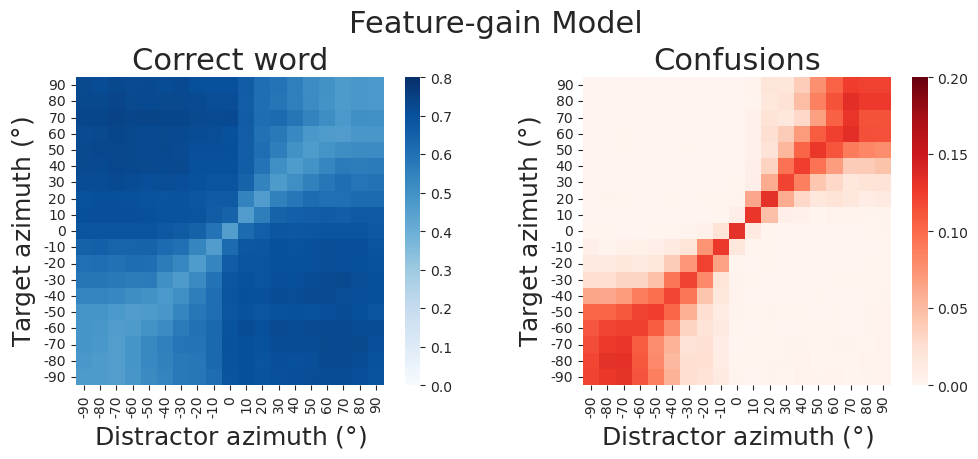

In [83]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']


model = 'Feature-gain Model'
fontsize=22
to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0) & grouped_results.model.eq(model)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
max_acc = round(total_acc.max(), 1)
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=True,ax=axs[0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
max_conf = round(total_con.max(), 1)
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.2, cmap='Reds', cbar=True,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
    ax.set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# axs[0].set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
# axs[0].set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

# make colorbar match heatmap size

# set confusions colorbar ticks to 0.5 increments
cbar_1 = axs[1].collections[0].colorbar
cbar_1.set_ticks(np.arange(0, 0.21, 0.05))
plt.suptitle(model, y=1.05, fontsize=fontsize)

for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig(outfig_dest/'azim_heatmaps.svg', trasnsparent=True, bbox_inches='tight')
plt.savefig(outfig_dest/'azimuth_heatmaps_v08_learned_no_cue.svg', transparent=True, bbox_inches='tight')
# plt.savefig(outfig_dest/'azimuth_heatmaps_half_coloc_v07.pdf', transparent=True, bbox_inches='tight')

# plt.tight_layout()

In [84]:
to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean().reset_index().query('target_azim == 0 & distractor_azim ==0' ).sort_values('distractor_azim')

,target_azim,distractor_azim,accuracy_mean
180,0,0,0.457541


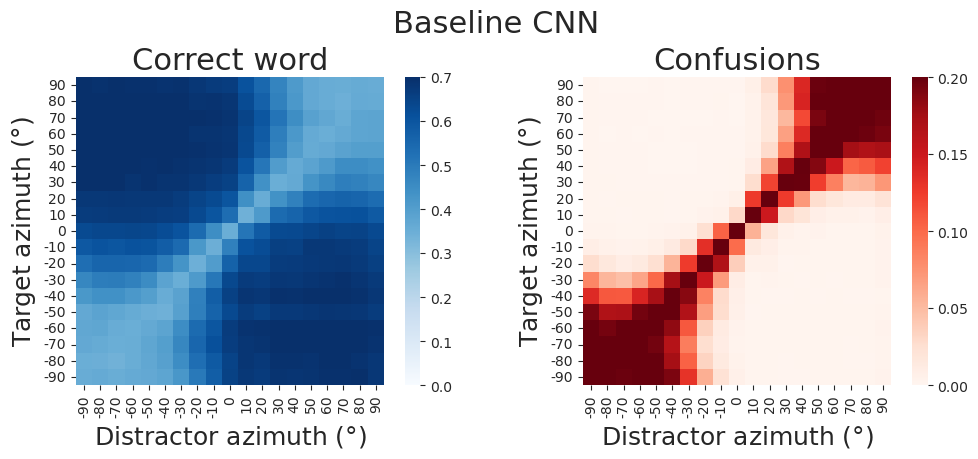

In [85]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']


model = 'Baseline CNN'
fontsize=22
to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0) & grouped_results.model.eq(model)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
max_acc = round(total_acc.max(), 1 ) 
sns.heatmap(total_acc.unstack(), vmin=0, vmax=max_acc, cmap='Blues', cbar=True,ax=axs[0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
max_conf = round(total_con.max(),1) 
sns.heatmap(total_con.unstack(), vmin=0, vmax=max_conf, cmap='Reds', cbar=True,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
    ax.set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# axs[0].set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
# axs[0].set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

# make colorbar match heatmap size

# set confusions colorbar ticks to 0.5 increments
cbar_1 = axs[1].collections[0].colorbar
cbar_1.set_ticks(np.arange(0, max_conf + 0.01, 0.05))
plt.suptitle(model, y=1.05, fontsize=fontsize)

for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig(outfig_dest/'azim_heatmaps.svg', trasnsparent=True, bbox_inches='tight')
# plt.savefig(outfig_dest/'azimuth_heatmaps_half_coloc_v07.svg', transparent=True, bbox_inches='tight')
# plt.savefig(outfig_dest/'azimuth_heatmaps_half_coloc_v07.pdf', transparent=True, bbox_inches='tight')

# plt.tight_layout()

___
## Line plots for reference

/tmp/ipykernel_3001187/352978534.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


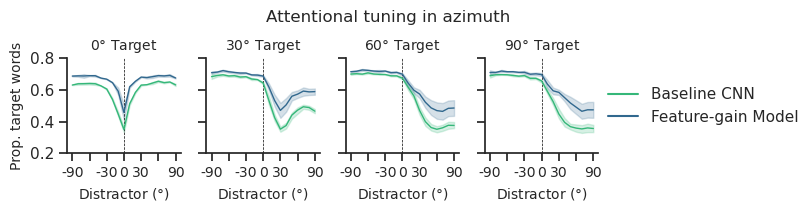

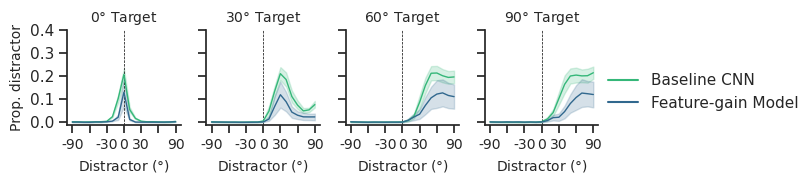

In [86]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")


models = ['Feature-gain Model', 'Baseline CNN' ]
cmap = sns.color_palette("viridis", n_colors=len(models))
palette = dict(zip(models, cmap))



to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,30,60,90])) & (grouped_results.distractor_elev == 0)]

to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='folded_distractor_azim', y='accuracy_mean', 
               hue='model',
                  kind='line', errorbar=('ci', 95),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. target words", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.2, 0.81, 0.2))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_acc.svg', transparent=True, bbox_inches='tight')

# plot confusions
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='folded_distractor_azim', y='confusions_mean', 
                 hue='model',
                  kind='line', errorbar=('ci', 95),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. distractor", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.0, 0.41, 0.1))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
# plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)


# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_conf.svg', transparent=True, bbox_inches='tight')

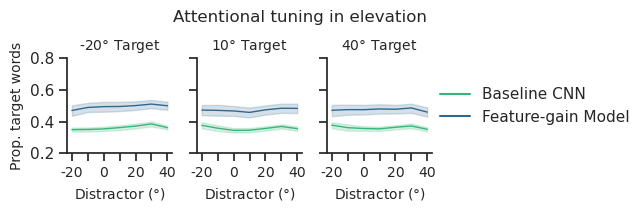

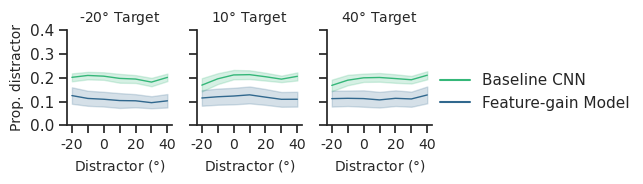

In [87]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")


models = ['Feature-gain Model', 'Baseline CNN' ]
cmap = sns.color_palette("viridis", n_colors=len(models))
palette = dict(zip(models, cmap))



to_plot = grouped_results[(grouped_results.azim_delta == 0) & (grouped_results.abs_target_azim.isin([0,30,90])) & (grouped_results.target_elev != 0 )]

# to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
# to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='distractor_elev', y='accuracy_mean', 
               hue='model',
                  kind='line', errorbar=('ci', 95),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. target words", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.20, 0.81, 0.2))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)



# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in elevation', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_acc.svg', transparent=True, bbox_inches='tight')

# plot confusions
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='distractor_elev', y='confusions_mean', 
                 hue='model',
                  kind='line', errorbar=('ci', 95),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. distractor", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.0, 0.41, 0.1))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)


# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
# plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)


# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_conf.svg', transparent=True, bbox_inches='tight')

/tmp/ipykernel_493091/2807185100.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


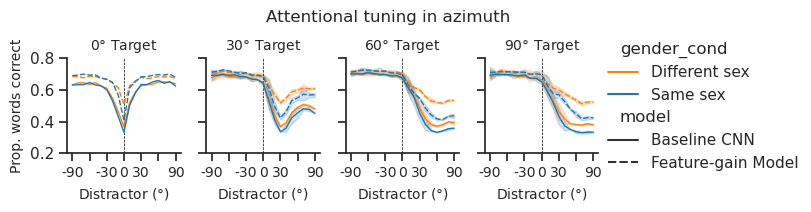

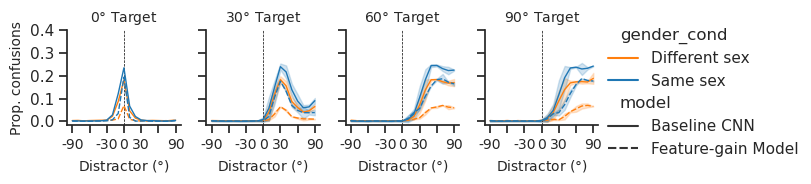

In [9]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")


palette = {'Same sex':'tab:blue', 'Different sex':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,30,60,90])) & (grouped_results.distractor_elev == 0)]

to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='folded_distractor_azim', y='accuracy_mean', 
                 hue='gender_cond', style='model',
                  kind='line', errorbar=('se', 2),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. words correct", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.2, 0.81, 0.2))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_acc.svg', transparent=True, bbox_inches='tight')

# plot confusions
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='folded_distractor_azim', y='confusions_mean', 
                 hue='gender_cond',  style='model',
                  kind='line', errorbar=('se', 2),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. confusions", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.0, 0.41, 0.1))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
# plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)


# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_conf.svg', transparent=True, bbox_inches='tight')

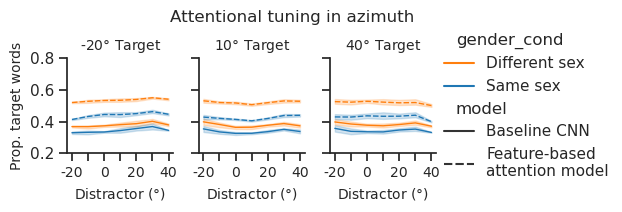

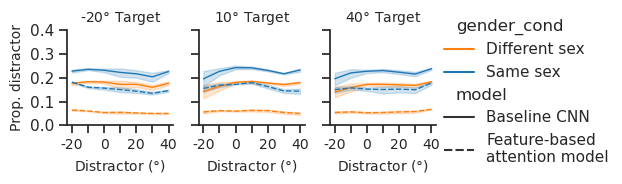

In [18]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")


models = ['Feature-based\nattention model', 'Baseline CNN' ]

palette = {'Same sex':'tab:blue', 'Different sex':'tab:orange'}  



to_plot = grouped_results[(grouped_results.azim_delta == 0) & (grouped_results.abs_target_azim.isin([0,30,90])) & (grouped_results.target_elev != 0 )]

# to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
# to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='distractor_elev', y='accuracy_mean', 
               hue='gender_cond', style='model',
                  kind='line', errorbar=('ci', 95),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. target words", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.20, 0.81, 0.2))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)



# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_acc.svg', transparent=True, bbox_inches='tight')

# plot confusions
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=1, zorder=5,
                 x='distractor_elev', y='confusions_mean', 
                 hue='gender_cond', style='model',
                  kind='line', errorbar=('ci', 95),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. distractor", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.0, 0.41, 0.1))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)


# change legend title 
g._legend.set_title('')

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
# plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)


# plt.savefig(outfig_dest/'azimuth_tuning_w_fb_half_coloc_v07_conf.svg', transparent=True, bbox_inches='tight')